In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from tqdm import tqdm

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score)

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# from google.colab import drive
# drive.mount('/content/drive')
# # === Dataset Paths ===
# BASE_DIR = r"D:\tugas\skripsi\Deam_Dataset"
# AUDIO_DIR = os.path.join(BASE_DIR, "DEAM_audio", "MEMD_audio")
# ANNOT_DIR = os.path.join(BASE_DIR, "DEAM_Annotations", "annotations",
#                          "annotations averaged per song", "song_level")

# # --- Load annotation CSVs ---
# annot_file_1 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_1_2000.csv")
# annot_file_2 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_2000_2058.csv")

# df1 = pd.read_csv(annot_file_1)
# df2 = pd.read_csv(annot_file_2)

# # Standardize column names (strip whitespace)
# df1.columns = df1.columns.str.strip()
# df2.columns = df2.columns.str.strip()

# print(f"Annotations file 1 shape: {df1.shape}")
# print(f"Annotations file 2 shape: {df2.shape}")
# print(f"\nFile 1 columns: {list(df1.columns)}")
# print(f"File 2 columns: {list(df2.columns)}")
# print(f"\nFile 1 sample:")
# df1.head()

# # Import library yang dibutuhkan
# import os
# import pandas as pd

# # Sambungkan Google Colab dengan Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# # === Dataset Paths ===
# # Menggunakan path Google Drive yang baru
# BASE_DIR = "/content/drive/MyDrive/DEAM_Dataset"
# AUDIO_DIR = os.path.join(BASE_DIR, "DEAM_audio", "MEMD_audio")
# ANNOT_DIR = os.path.join(BASE_DIR, "DEAM_Annotations", "annotations",
#                          "annotations averaged per song", "song_level")

# # --- Load annotation CSVs ---
# annot_file_1 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_1_2000.csv")
# annot_file_2 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_2000_2058.csv")

# df1 = pd.read_csv(annot_file_1)
# df2 = pd.read_csv(annot_file_2)

# # Standardize column names (strip whitespace)
# df1.columns = df1.columns.str.strip()
# df2.columns = df2.columns.str.strip()

# print(f"Annotations file 1 shape: {df1.shape}")
# print(f"Annotations file 2 shape: {df2.shape}")
# print(f"\nFile 1 columns: {list(df1.columns)}")
# print(f"File 2 columns: {list(df2.columns)}")
# print(f"\nFile 1 sample:")
# df1.head()

# === Dataset Paths ===
# Using the native Linux path since we are running in WSL
BASE_DIR = "/home/beingyou/music_emotion_project/DEAM_Dataset"
AUDIO_DIR = os.path.join(BASE_DIR, "DEAM_audio", "MEMD_audio")
ANNOT_DIR = os.path.join(BASE_DIR, "DEAM_Annotations", "annotations",
                         "annotations averaged per song", "song_level")

# --- Load annotation CSVs ---
annot_file_1 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_1_2000.csv")
annot_file_2 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_2000_2058.csv")

df1 = pd.read_csv(annot_file_1)
df2 = pd.read_csv(annot_file_2)

# Standardize column names (strip whitespace)
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

print(f"Annotations file 1 shape: {df1.shape}")
print(f"Annotations file 2 shape: {df2.shape}")
print(f"\nFile 1 columns: {list(df1.columns)}")
print(f"File 2 columns: {list(df2.columns)}")
print(f"\nFile 1 sample:")
df1.head()

Annotations file 1 shape: (1744, 5)
Annotations file 2 shape: (58, 13)

File 1 columns: ['song_id', 'valence_mean', 'valence_std', 'arousal_mean', 'arousal_std']
File 2 columns: ['song_id', 'valence_mean', 'valence_std', 'valence_ max_mean', 'valence_max_std', 'valence_min_mean', 'valence_min_std', 'arousal_mean', 'arousal_std', 'arousal_max_mean', 'arousal_max_std', 'arousal_min_mean', 'arousal_min_std']

File 1 sample:


,song_id,valence_mean,valence_std,arousal_mean,arousal_std
0,2,3.1,0.94,3.0,0.63
1,3,3.5,1.75,3.3,1.62
2,4,5.7,1.42,5.5,1.63
3,5,4.4,2.01,5.3,1.85
4,7,5.8,1.47,6.4,1.69


In [3]:
# Select common columns: song_id, valence_mean, arousal_mean
# File 1 has: song_id, valence_mean, valence_std, arousal_mean, arousal_std
# File 2 has more columns — we only need the common ones
common_cols = ['song_id', 'valence_mean', 'valence_std', 'arousal_mean', 'arousal_std']

df1_sel = df1[common_cols].copy()
df2_sel = df2[common_cols].copy()

# Merge both annotation dataframes
annotations = pd.concat([df1_sel, df2_sel], ignore_index=True)
annotations = annotations.drop_duplicates(subset='song_id').reset_index(drop=True)

print(f"Total annotated songs: {len(annotations)}")
print(f"\nMissing values:\n{annotations.isnull().sum()}")
print(f"\n--- Descriptive Statistics ---")
annotations[['valence_mean', 'arousal_mean']].describe()


Total annotated songs: 1802

Missing values:
song_id         0
valence_mean    0
valence_std     0
arousal_mean    0
arousal_std     0
dtype: int64

--- Descriptive Statistics ---


,valence_mean,arousal_mean
count,1802.000000,1802.000000
mean,4.904145,4.814029
std,1.174240,1.282187
min,1.600000,1.600000
25%,4.100000,3.800000
50%,4.900000,4.900000
75%,5.800000,5.800000
max,8.400000,8.100000


Total audio files: 1802
Annotated songs with audio: 1802
Annotated songs without audio: 0

Final dataset size: 1802 songs


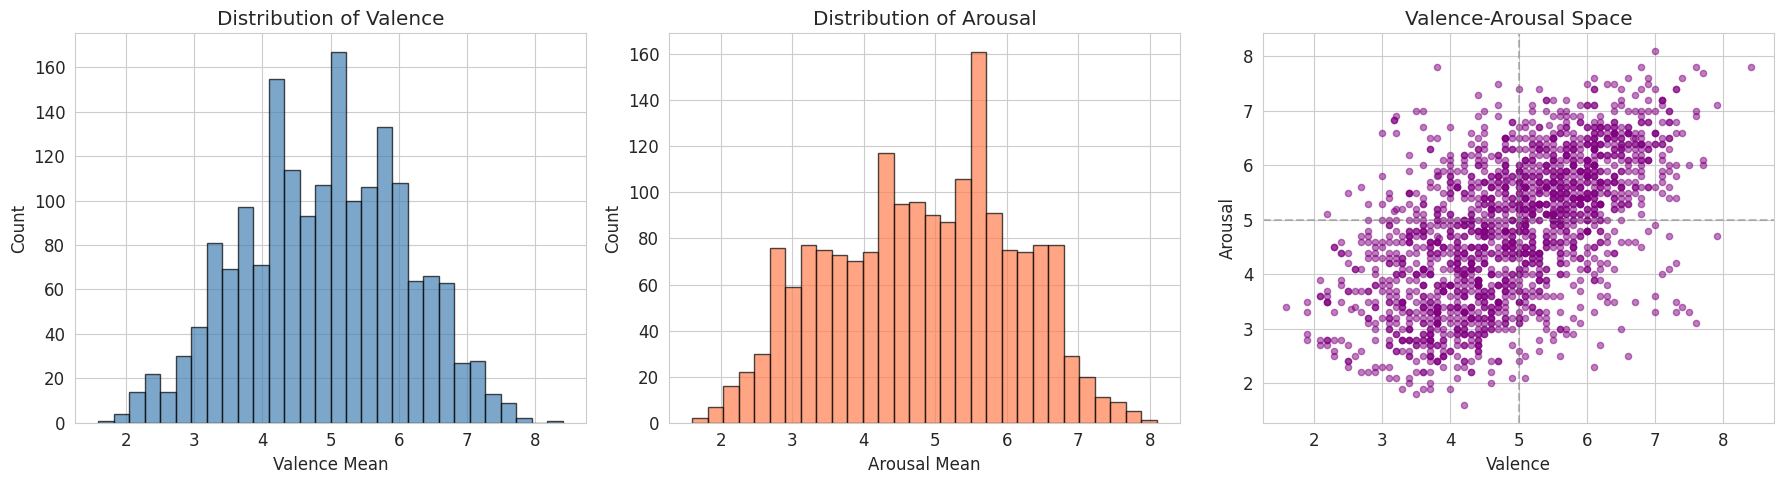

In [4]:
# Check which annotated songs have audio files available
available_audio = set()
for f in os.listdir(AUDIO_DIR):
    if f.endswith('.mp3'):
        song_id = int(os.path.splitext(f)[0])
        available_audio.add(song_id)

annotations['has_audio'] = annotations['song_id'].isin(available_audio)
print(f"Total audio files: {len(available_audio)}")
print(f"Annotated songs with audio: {annotations['has_audio'].sum()}")
print(f"Annotated songs without audio: {(~annotations['has_audio']).sum()}")

# Keep only songs that have audio
annotations = annotations[annotations['has_audio']].drop(columns='has_audio').reset_index(drop=True)
print(f"\nFinal dataset size: {len(annotations)} songs")

# Plot valence-arousal distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(annotations['valence_mean'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Valence Mean')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Valence')

axes[1].hist(annotations['arousal_mean'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Arousal Mean')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Arousal')

axes[2].scatter(annotations['valence_mean'], annotations['arousal_mean'], alpha=0.5, s=20, c='purple')
axes[2].set_xlabel('Valence')
axes[2].set_ylabel('Arousal')
axes[2].set_title('Valence-Arousal Space')
axes[2].axhline(y=5, color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(x=5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# === Multi-Scale Mel Spectrogram Extraction ===
# 3 different configurations to capture different time-frequency resolutions:
#   Channel 1: Fine frequency (128 mels, hop=512)  — detailed spectral content
#   Channel 2: Coarse frequency (64 mels, hop=256)  — better time resolution
#   Channel 3: Wide frequency (128 mels, hop=1024) — broader temporal context
SR = 22050
DURATION = 45
N_FFT = 2048

MEL_CONFIGS = [
    {"n_mels": 128, "hop_length": 512,  "label": "fine_freq"},
    {"n_mels": 64,  "hop_length": 256,  "label": "fine_time"},
    {"n_mels": 128, "hop_length": 1024, "label": "wide_context"},
]


def extract_multi_mel(file_path, sr=SR, duration=DURATION, n_fft=N_FFT):
    """
    Extract multiple Mel spectrograms with different configurations.

    Returns:
        dict mapping config label -> log-scaled Mel spectrogram, or None on error
    """
    try:
        y, sr_out = librosa.load(file_path, sr=sr, duration=duration, mono=True)
        result = {}
        for cfg in MEL_CONFIGS:
            mel_spec = librosa.feature.melspectrogram(
                y=y, sr=sr_out,
                n_mels=cfg["n_mels"],
                hop_length=cfg["hop_length"],
                n_fft=n_fft
            )
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
            result[cfg["label"]] = mel_spec_db
        return result
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


# === Extract Multi-Scale Mel Spectrograms ===
mel_spectrograms_multi = {}
failed_songs = []

print(f"Extracting Multi-Scale Mel Spectrograms for {len(annotations)} songs...")
print(f"Configs: {[c['label'] for c in MEL_CONFIGS]}\n")

for idx, row in tqdm(annotations.iterrows(), total=len(annotations), desc="Extracting"):
    song_id = int(row['song_id'])
    audio_path = os.path.join(AUDIO_DIR, f"{song_id}.mp3")

    result = extract_multi_mel(audio_path)
    if result is not None:
        mel_spectrograms_multi[song_id] = result
    else:
        failed_songs.append(song_id)

# Keep backward-compatible reference for visualization cells
mel_spectrograms = {sid: data["fine_freq"] for sid, data in mel_spectrograms_multi.items()}

print(f"\nSuccessfully extracted: {len(mel_spectrograms_multi)} songs (3 channels each)")
print(f"Failed: {len(failed_songs)} songs")
if failed_songs:
    print(f"Failed song IDs: {failed_songs[:20]}{'...' if len(failed_songs) > 20 else ''}")

Extracting Mel Spectrograms for 1802 songs...
Parameters: SR=22050, N_MELS=128, HOP_LENGTH=512, DURATION=45s



Extracting:   0%|          | 0/1802 [00:00<?, ?it/s]

Extracting: 100%|██████████| 1802/1802 [05:23<00:00,  5.56it/s]


Successfully extracted: 1802 spectrograms
Failed: 0 songs


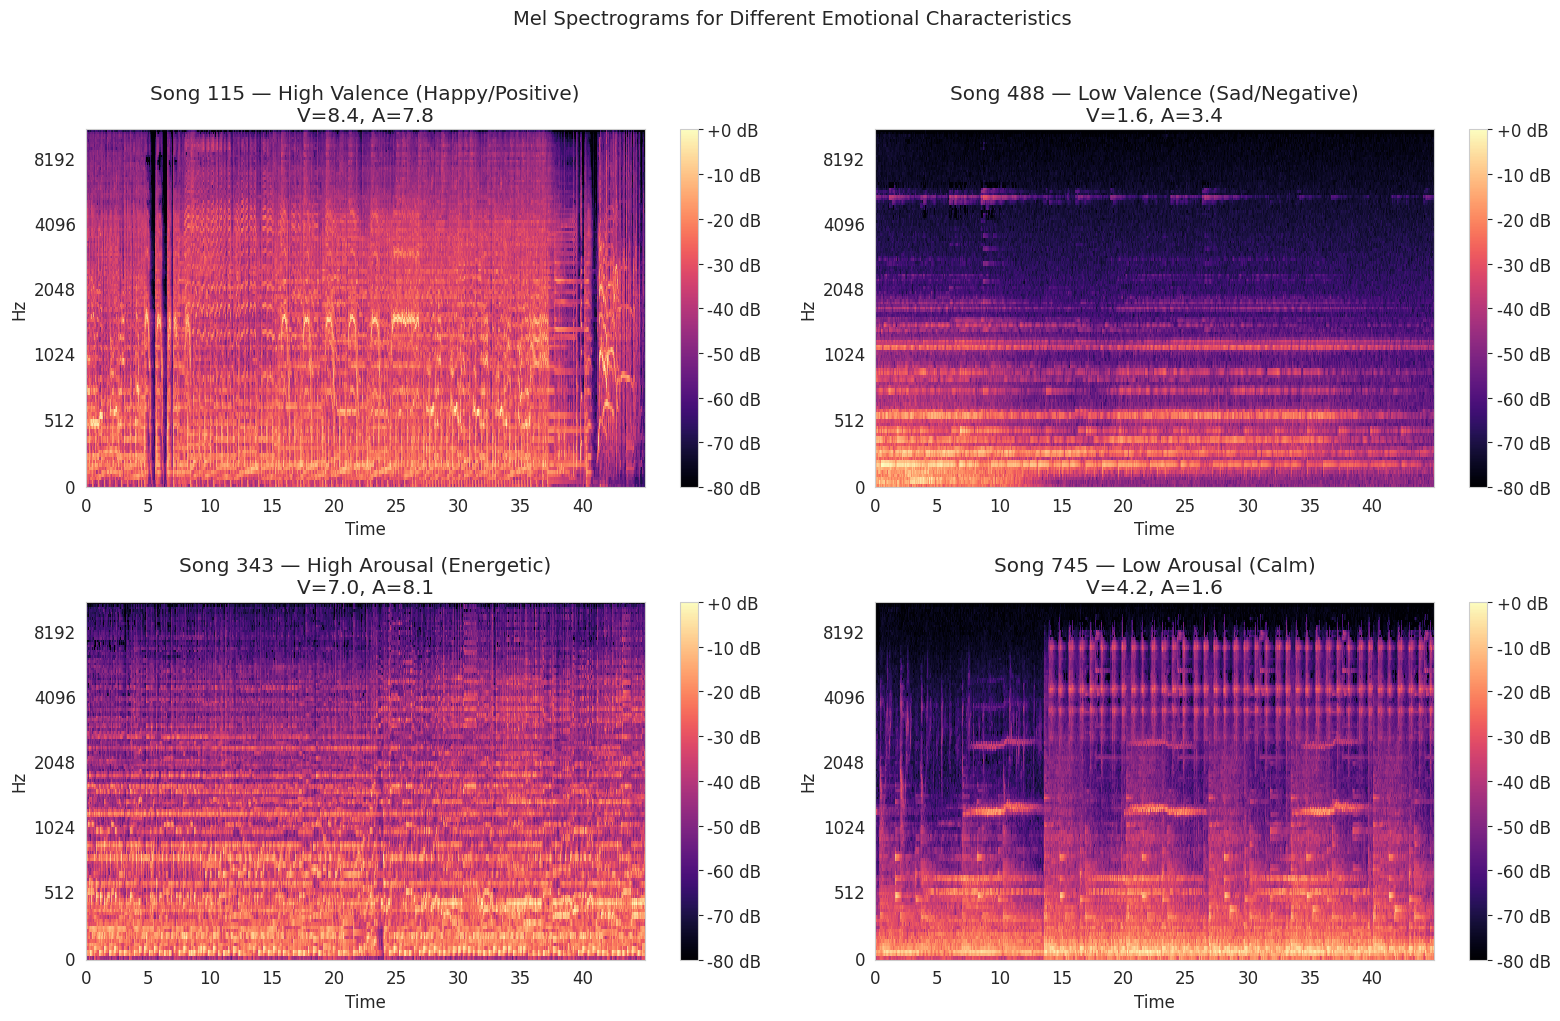

In [ ]:
# Find songs with extreme emotional characteristics
valid_annot = annotations[annotations['song_id'].isin(mel_spectrograms.keys())].copy()

# Sort by valence to find extremes
high_valence = valid_annot.nlargest(1, 'valence_mean').iloc[0]
low_valence = valid_annot.nsmallest(1, 'valence_mean').iloc[0]
high_arousal = valid_annot.nlargest(1, 'arousal_mean').iloc[0]
low_arousal = valid_annot.nsmallest(1, 'arousal_mean').iloc[0]

samples = [
    (high_valence, "High Valence (Happy/Positive)"),
    (low_valence, "Low Valence (Sad/Negative)"),
    (high_arousal, "High Arousal (Energetic)"),
    (low_arousal, "Low Arousal (Calm)"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# Use the first mel config's hop_length for display
_display_hop = MEL_CONFIGS[0]["hop_length"]

for i, (song_row, title) in enumerate(samples):
    sid = int(song_row['song_id'])
    mel_spec = mel_spectrograms[sid]

    img = librosa.display.specshow(
        mel_spec, sr=SR, hop_length=_display_hop,
        x_axis='time', y_axis='mel', ax=axes[i]
    )
    axes[i].set_title(f"Song {sid} — {title}\n"
                      f"V={song_row['valence_mean']:.1f}, A={song_row['arousal_mean']:.1f}")
    fig.colorbar(img, ax=axes[i], format="%+2.0f dB")

plt.suptitle("Mel Spectrograms for Different Emotional Characteristics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Dropped 758 ambiguous borderline samples (margin=0.5)

Emotion category distribution:
emotion
Sad/Depressed    486
Happy/Excited    390
Angry/Tense       90
Calm/Relaxed      78
Name: count, dtype: int64

Total samples: 1044


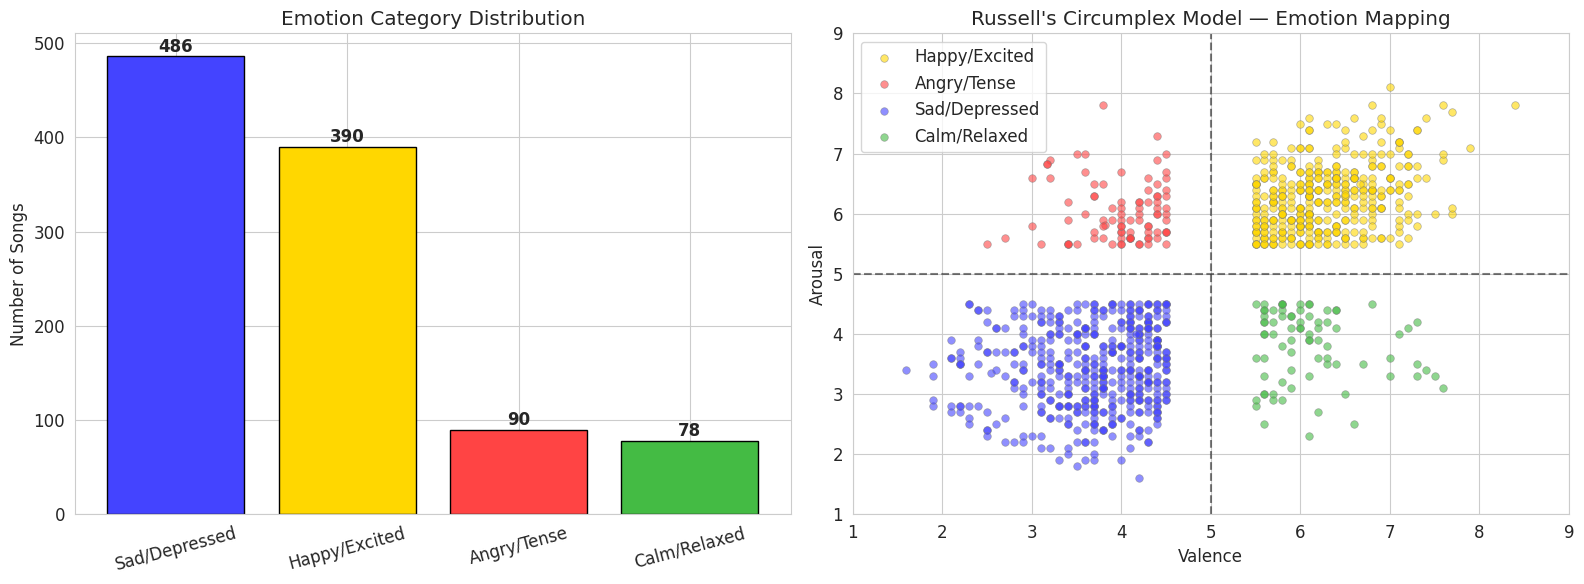

In [7]:
MARGIN = 0.5 # Margin to avoid borderline cases
def map_emotion(valence, arousal, threshold=5.0, margin=MARGIN):
    """
    Map valence and arousal values to emotion categories using Russell's Circumplex Model.
    Samples within 'margin' of the threshold are dropped as ambiguous.

    Parameters:
        valence: Valence value (1-9 scale)
        arousal: Arousal value (1-9 scale)
        threshold: Midpoint threshold (default 5.0 for DEAM's 1-9 scale)
        margin: Distance from threshold within which samples are considered ambiguous

    Returns:
        Emotion category string, or None if ambiguous
    """
    # Drop borderline samples that are too close to the decision boundary
    if abs(valence - threshold) < margin or abs(arousal - threshold) < margin:
        return None

    if valence >= threshold and arousal >= threshold:
        return "Happy/Excited"
    elif valence < threshold and arousal >= threshold:
        return "Angry/Tense"
    elif valence < threshold and arousal < threshold:
        return "Sad/Depressed"
    else:  # valence >= threshold and arousal < threshold
        return "Calm/Relaxed"


# Apply emotion mapping
valid_annot = annotations[annotations['song_id'].isin(mel_spectrograms.keys())].copy()
valid_annot['emotion'] = valid_annot.apply(
    lambda row: map_emotion(row['valence_mean'], row['arousal_mean']), axis=1
)

# Filter out ambiguous (borderline) samples
n_before = len(valid_annot)
valid_annot = valid_annot.dropna(subset=['emotion']).reset_index(drop=True)
n_dropped = n_before - len(valid_annot)
print(f"Dropped {n_dropped} ambiguous borderline samples (margin={MARGIN})")

print("\nEmotion category distribution:")
print(valid_annot['emotion'].value_counts())
print(f"\nTotal samples: {len(valid_annot)}")

# Visualize emotion distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
emotion_counts = valid_annot['emotion'].value_counts()
colors = {'Happy/Excited': '#FFD700', 'Angry/Tense': '#FF4444',
          'Sad/Depressed': '#4444FF', 'Calm/Relaxed': '#44BB44'}
bars = axes[0].bar(emotion_counts.index, emotion_counts.values,
                   color=[colors[e] for e in emotion_counts.index], edgecolor='black')
axes[0].set_ylabel('Number of Songs')
axes[0].set_title('Emotion Category Distribution')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, emotion_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontweight='bold')

# Scatter plot colored by emotion
for emotion, color in colors.items():
    subset = valid_annot[valid_annot['emotion'] == emotion]
    axes[1].scatter(subset['valence_mean'], subset['arousal_mean'],
                    c=color, label=emotion, alpha=0.6, s=30, edgecolors='gray', linewidths=0.5)

axes[1].axhline(y=5, color='black', linestyle='--', alpha=0.5)
axes[1].axvline(x=5, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Valence')
axes[1].set_ylabel('Arousal')
axes[1].set_title("Russell's Circumplex Model — Emotion Mapping")
axes[1].legend(loc='upper left')
axes[1].set_xlim(1, 9)
axes[1].set_ylim(1, 9)

plt.tight_layout()
plt.show()

In [ ]:
def extract_feature_vector(mel_spec_db):
    """
    Extract a fixed-length feature vector from a Mel spectrogram by computing
    summary statistics across the time axis for each Mel frequency band.

    Parameters:
        mel_spec_db: Log-scaled Mel spectrogram (n_mels x time_frames)

    Returns:
        Feature vector of shape (n_mels * 4,) containing mean, std, min, max per band
    """
    mel_mean = np.mean(mel_spec_db, axis=1)
    mel_std = np.std(mel_spec_db, axis=1)
    mel_min = np.min(mel_spec_db, axis=1)
    mel_max = np.max(mel_spec_db, axis=1)

    return np.concatenate([mel_mean, mel_std, mel_min, mel_max])


# Build feature matrix X and label array y
feature_list = []
label_list = []
song_ids_list = []
valence_list = []
arousal_list = []

for idx, row in valid_annot.iterrows():
    song_id = int(row['song_id'])
    if song_id in mel_spectrograms:
        mel_spec = mel_spectrograms[song_id]
        features = extract_feature_vector(mel_spec)
        feature_list.append(features)
        label_list.append(row['emotion'])
        song_ids_list.append(song_id)
        valence_list.append(row['valence_mean'])
        arousal_list.append(row['arousal_mean'])

X = np.array(feature_list)
y = np.array(label_list)
song_ids_arr = np.array(song_ids_list)
valence_arr = np.array(valence_list)
arousal_arr = np.array(arousal_list)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

n_mels_used = MEL_CONFIGS[0]["n_mels"]
print(f"Feature matrix shape: {X.shape}")
print(f"Label array shape: {y.shape}")
print(f"Feature vector size per track: {X.shape[1]} "
      f"({n_mels_used} Mel bands × 4 statistics)")
print(f"\nLabel encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"\nClass distribution:")
for cls, count in zip(*np.unique(y, return_counts=True)):
    print(f"  {cls}: {count} ({count/len(y)*100:.1f}%)")

Feature matrix shape: (1044, 512)
Label array shape: (1044,)
Feature vector size per track: 512 (128 Mel bands × 4 statistics)

Label encoding: {'Angry/Tense': 0, 'Calm/Relaxed': 1, 'Happy/Excited': 2, 'Sad/Depressed': 3}

Class distribution:
  Angry/Tense: 90 (8.6%)
  Calm/Relaxed: 78 (7.5%)
  Happy/Excited: 390 (37.4%)
  Sad/Depressed: 486 (46.6%)


In [9]:
# ============================================================
# CNN Model — GPU Configuration & TensorFlow Imports
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn.utils.class_weight import compute_class_weight

# --- GPU Setup ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU(s) detected: {len(gpus)}")
    for gpu in gpus:
        print(f"  {gpu.name}")
    USE_GPU = True
else:
    print("No GPU detected — training will use CPU")
    USE_GPU = False

print(f"TensorFlow version: {tf.__version__}")
print(f"Devices: {[d.name for d in tf.config.list_physical_devices()]}")

2026-03-09 12:46:09.046637: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-09 12:46:09.884959: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-09 12:46:10.188225: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-09 12:46:11.821044: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-09 12:46:21.819306: W tensorflow/compiler/tf2

GPU(s) detected: 1
  /physical_device:GPU:0
TensorFlow version: 2.17.0
Devices: ['/physical_device:CPU:0', '/physical_device:GPU:0']


I0000 00:00:1773035189.874928    1178 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773035192.478559    1178 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773035192.478669    1178 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [ ]:
# ============================================================
# Prepare 3-Channel Data for CNN (Multi-Scale Mel Spectrograms)
# Each channel = different mel config, resized to 128x128
# ============================================================
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight

TARGET_FREQ = 128  # Resize all channels to 128 mel bands
TARGET_TIME = 128  # Resize all channels to 128 time frames

def resize_mel(mel_spec_db, target_freq=TARGET_FREQ, target_time=TARGET_TIME):
    """Resize mel spectrogram to (target_freq, target_time) via average pooling."""
    n_mels, n_frames = mel_spec_db.shape

    # --- Frequency axis ---
    if n_mels > target_freq:
        bin_f = n_mels // target_freq
        trimmed_f = mel_spec_db[:bin_f * target_freq, :]
        mel_spec_db = trimmed_f.reshape(target_freq, bin_f, n_frames).mean(axis=1)
    elif n_mels < target_freq:
        pad_f = target_freq - n_mels
        mel_spec_db = np.pad(mel_spec_db, ((0, pad_f), (0, 0)),
                             mode='constant', constant_values=mel_spec_db.min())
    n_mels = target_freq

    # --- Time axis ---
    n_frames = mel_spec_db.shape[1]
    if n_frames > target_time:
        bin_t = n_frames // target_time
        trimmed_t = mel_spec_db[:, :bin_t * target_time]
        mel_spec_db = trimmed_t.reshape(n_mels, target_time, bin_t).mean(axis=2)
    elif n_frames < target_time:
        pad_t = target_time - n_frames
        mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, pad_t)),
                             mode='constant', constant_values=mel_spec_db.min())
    return mel_spec_db[:target_freq, :target_time]

def normalize_per_sample(mel):
    """Per-sample Z-score normalization."""
    mean = mel.mean()
    std = mel.std()
    if std < 1e-6:
        return mel - mean
    return (mel - mean) / std

# Build 3-channel CNN dataset
X_cnn_list = []
y_cnn_list = []

channel_labels = [cfg["label"] for cfg in MEL_CONFIGS]

for idx, row in valid_annot.iterrows():
    song_id = int(row['song_id'])
    if song_id in mel_spectrograms_multi:
        channels = []
        for label in channel_labels:
            mel = mel_spectrograms_multi[song_id][label]
            mel_resized = resize_mel(mel)
            mel_normed = normalize_per_sample(mel_resized)
            channels.append(mel_normed)
        # Stack 3 channels: (128, 128, 3)
        X_cnn_list.append(np.stack(channels, axis=-1))
        y_cnn_list.append(row['emotion'])

X_cnn = np.array(X_cnn_list, dtype=np.float32)  # (N, 128, 128, 3)
y_cnn = np.array(y_cnn_list)

le_cnn = LabelEncoder()
y_cnn_encoded = le_cnn.fit_transform(y_cnn)
NUM_CLASSES = len(le_cnn.classes_)
y_cnn_onehot = tf.keras.utils.to_categorical(y_cnn_encoded, NUM_CLASSES)

print(f"CNN input shape: {X_cnn.shape}  (3 channels = 3 mel configs)")
print(f"Classes: {list(le_cnn.classes_)}")

# --- Split BEFORE oversampling (no leakage) ---
X_tv, X_test, y_tv, y_test, idx_tv, idx_te = train_test_split(
    X_cnn, y_cnn_onehot, np.arange(len(X_cnn)),
    test_size=0.15, random_state=42, stratify=y_cnn_encoded
)
y_tv_labels = y_cnn_encoded[idx_tv]
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.176, random_state=42, stratify=y_tv_labels
)

print(f"Before oversampling -- Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

# --- Compute class weights for balanced training ---
y_train_labels = np.argmax(y_train, axis=1)
class_weights_arr = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train_labels)
class_weights = dict(enumerate(class_weights_arr))
print(f"\nClass weights: {class_weights}")

# --- Plain oversampling ---
class_counts = Counter(y_train_labels)
max_count = max(class_counts.values())
print(f"Class counts before: {dict(sorted(class_counts.items()))}")

X_list = list(X_train)
y_list = list(y_train)
rng = np.random.RandomState(42)

for cls_id, count in class_counts.items():
    if count < max_count:
        cls_mask = y_train_labels == cls_id
        cls_X = X_train[cls_mask]
        cls_y = y_train[cls_mask]
        n_needed = max_count - count
        indices = rng.choice(len(cls_X), size=n_needed, replace=True)
        X_list.extend(cls_X[indices])
        y_list.extend(cls_y[indices])

X_train = np.array(X_list, dtype=np.float32)
y_train = np.array(y_list, dtype=np.float32)

shuffle_idx = rng.permutation(len(X_train))
X_train = X_train[shuffle_idx]
y_train = y_train[shuffle_idx]

y_bal = np.argmax(y_train, axis=1)
print(f"Class counts after:  {dict(sorted(Counter(y_bal).items()))}")
print(f"After oversampling -- Train: {X_train.shape[0]}")

CNN input shape: (1044, 128, 256, 1)
Classes: ['Angry/Tense', 'Calm/Relaxed', 'Happy/Excited', 'Sad/Depressed']
Before oversampling -- Train: 730, Val: 157, Test: 157
Class counts before: {0: 63, 1: 54, 2: 273, 3: 340}
Class counts after:  {0: 340, 1: 340, 2: 340, 3: 340}
After oversampling -- Train: 1360


In [ ]:
# ============================================================
# CNN with Transfer Learning (EfficientNetB0) + Attention Layer
# ============================================================

tf.keras.backend.clear_session()

# --- tf.data augmentation ---
def tf_time_shift(mel, max_shift=10):
    shift = tf.random.uniform([], -max_shift, max_shift, dtype=tf.int32)
    return tf.roll(mel, shift=shift, axis=1)

def tf_add_noise(mel, noise_std=0.02):
    return mel + tf.random.normal(tf.shape(mel), stddev=noise_std)

def tf_freq_mask(mel, max_mask=12):
    n_mels = tf.shape(mel)[0]
    mask_len = tf.random.uniform([], 1, max_mask, dtype=tf.int32)
    start = tf.random.uniform([], 0, n_mels - mask_len, dtype=tf.int32)
    mask = tf.concat([
        tf.ones([start, tf.shape(mel)[1], tf.shape(mel)[2]]),
        tf.zeros([mask_len, tf.shape(mel)[1], tf.shape(mel)[2]]),
        tf.ones([n_mels - start - mask_len, tf.shape(mel)[1], tf.shape(mel)[2]])
    ], axis=0)
    return mel * mask

def tf_time_mask(mel, max_mask=12):
    n_time = tf.shape(mel)[1]
    mask_len = tf.random.uniform([], 1, max_mask, dtype=tf.int32)
    start = tf.random.uniform([], 0, n_time - mask_len, dtype=tf.int32)
    mask = tf.concat([
        tf.ones([tf.shape(mel)[0], start, tf.shape(mel)[2]]),
        tf.zeros([tf.shape(mel)[0], mask_len, tf.shape(mel)[2]]),
        tf.ones([tf.shape(mel)[0], n_time - start - mask_len, tf.shape(mel)[2]])
    ], axis=1)
    return mel * mask

def augment_single(mel, label):
    """Augmentations at p=0.3 for 3-channel input."""
    mel = tf.cond(tf.random.uniform([]) < 0.3, lambda: tf_time_shift(mel), lambda: mel)
    mel = tf.cond(tf.random.uniform([]) < 0.3, lambda: tf_add_noise(mel), lambda: mel)
    mel = tf.cond(tf.random.uniform([]) < 0.3, lambda: tf_freq_mask(mel), lambda: mel)
    mel = tf.cond(tf.random.uniform([]) < 0.3, lambda: tf_time_mask(mel), lambda: mel)
    return mel, label

# --- Mixup ---
MIXUP_ALPHA = 0.1

def mixup_batch(images, labels):
    """Apply mixup to a batch."""
    batch_size = tf.shape(images)[0]
    lam = tf.numpy_function(
        lambda a: np.random.beta(a, a, size=()).astype(np.float32),
        [MIXUP_ALPHA], tf.float32
    )
    lam = tf.maximum(lam, 1.0 - lam)
    indices = tf.random.shuffle(tf.range(batch_size))
    images_shuffled = tf.gather(images, indices)
    labels_shuffled = tf.gather(labels, indices)
    lam_img = tf.reshape(lam, [1, 1, 1, 1])
    lam_lbl = tf.reshape(lam, [1, 1])
    return (lam_img * images + (1.0 - lam_img) * images_shuffled,
            lam_lbl * labels + (1.0 - lam_lbl) * labels_shuffled)


# --- Channel Attention (Squeeze-and-Excitation) ---
class ChannelAttention(layers.Layer):
    """Squeeze-and-Excitation block for channel-wise attention."""
    def __init__(self, reduction=16, **kwargs):
        super().__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        channels = input_shape[-1]
        self.gap = layers.GlobalAveragePooling2D()
        self.fc1 = layers.Dense(channels // self.reduction, activation='relu')
        self.fc2 = layers.Dense(channels, activation='sigmoid')

    def call(self, x):
        se = self.gap(x)
        se = self.fc1(se)
        se = self.fc2(se)
        se = tf.reshape(se, [-1, 1, 1, tf.shape(x)[-1]])
        return x * se

    def get_config(self):
        config = super().get_config()
        config.update({"reduction": self.reduction})
        return config


# --- Spatial Attention ---
class SpatialAttention(layers.Layer):
    """Spatial attention: highlights important frequency-time regions."""
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.conv = layers.Conv2D(1, self.kernel_size, padding='same', activation='sigmoid')

    def call(self, x):
        avg_pool = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(x, axis=-1, keepdims=True)
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        attn = self.conv(concat)
        return x * attn

    def get_config(self):
        config = super().get_config()
        config.update({"kernel_size": self.kernel_size})
        return config


# --- Build Transfer Learning Model with Attention ---
def build_transfer_attention_model(input_shape, num_classes, l2_reg=1e-4):
    """
    EfficientNetB0 backbone (pretrained on ImageNet) +
    Channel Attention (SE) + Spatial Attention (CBAM-style) +
    Dense classification head.

    Input: (128, 128, 3) — 3 channels from multi-scale mel spectrograms.
    """
    reg = regularizers.l2(l2_reg)
    inputs = layers.Input(shape=input_shape)

    # EfficientNetB0 backbone — freeze initially for transfer learning
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )
    # Freeze backbone initially (will unfreeze later for fine-tuning)
    base_model.trainable = False

    x = base_model.output  # (batch, 4, 4, 1280)

    # Channel attention (Squeeze-and-Excitation)
    x = ChannelAttention(reduction=16, name='channel_attention')(x)

    # Spatial attention
    x = SpatialAttention(kernel_size=7, name='spatial_attention')(x)

    # Global pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Dense classification head
    x = layers.Dense(256, kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.35)(x)

    x = layers.Dense(128, kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model, base_model

INPUT_SHAPE = X_train.shape[1:]  # (128, 128, 3)
model, base_model = build_transfer_attention_model(INPUT_SHAPE, NUM_CLASSES)

LABEL_SMOOTHING = 0.05

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)

# Count trainable vs frozen params
trainable = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
non_trainable = sum(tf.keras.backend.count_params(w) for w in model.non_trainable_weights)
print(f"Transfer Learning: EfficientNetB0 + Channel Attention + Spatial Attention")
print(f"Trainable params: {trainable:,}  |  Frozen params: {non_trainable:,}")
print(f"Label smoothing: {LABEL_SMOOTHING}, Mixup alpha: {MIXUP_ALPHA}")
print(f"Class weights: {class_weights}")
model.summary()

I0000 00:00:1773035200.681078    1178 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773035200.681211    1178 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773035200.681285    1178 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773035201.176486    1178 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773035201.176703    1178 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-09

Label smoothing: 0.05
Learning rate: 5e-4
L2 regularization: Dense layers only
Mixup alpha: 0.1


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 128, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 128, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 128, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 128, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 64, 128)    │             

 Total params: 1,276,260 (4.87 MB)

 Trainable params: 1,273,572 (4.86 MB)

 Non-trainable params: 2,688 (10.50 KB)

In [ ]:
# ============================================================
# Train: Phase 1 (frozen backbone) → Phase 2 (fine-tune)
# ============================================================

BATCH_SIZE = 32

# --- Data pipelines ---
train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(2048)
    .map(augment_single, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .map(lambda x, y: mixup_batch(x, y), num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# =====================
# PHASE 1: Train head only (backbone frozen), lr=1e-3
# =====================
print("=" * 60)
print("PHASE 1: Training classification head (backbone frozen)")
print("=" * 60)

early_stop_p1 = callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
)
reduce_lr_p1 = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1
)

history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop_p1, reduce_lr_p1],
    class_weight=class_weights,
    verbose=1
)

print(f"\nPhase 1 done — Best val_acc: {max(history_p1.history['val_accuracy']):.4f}")

# =====================
# PHASE 2: Unfreeze backbone and fine-tune with low lr
# =====================
print("\n" + "=" * 60)
print("PHASE 2: Fine-tuning entire model (backbone unfrozen)")
print("=" * 60)

base_model.trainable = True

# Recompile with much lower learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)

early_stop_p2 = callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)
reduce_lr_p2 = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1
)

history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_stop_p2, reduce_lr_p2],
    class_weight=class_weights,
    verbose=1
)

print(f"\nPhase 2 done — Best val_acc: {max(history_p2.history['val_accuracy']):.4f}")

# Combine histories for plotting
history_combined = {}
for key in history_p1.history:
    history_combined[key] = history_p1.history[key] + history_p2.history[key]

# Store in a simple namespace for compatibility with plot/eval cells
class CombinedHistory:
    pass
history = CombinedHistory()
history.history = history_combined

total_epochs = len(history_combined['loss'])
print(f"\nTotal epochs: {total_epochs}")
print(f"Best val_loss: {min(history_combined['val_loss']):.4f}")
print(f"Best val_accuracy: {max(history_combined['val_accuracy']):.4f}")

2026-03-09 12:47:00.628628: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 178257920 exceeds 10% of free system memory.
2026-03-09 12:47:02.069876: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 178257920 exceeds 10% of free system memory.


BATCH_SIZE=32, MAX_EPOCHS=150
EarlyStopping patience=15, ReduceLR patience=7
Augmentations: time_shift, noise, freq_mask, time_mask (p=0.3) + mixup(α=0.1)
Train samples: 1360, Input: (128, 256, 1)

Epoch 1/150


2026-03-09 12:47:03.144279: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 178257920 exceeds 10% of free system memory.
I0000 00:00:1773035237.983061    9422 service.cc:146] XLA service 0x792738009a80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773035237.983198    9422 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce GTX 1050, Compute Capability 6.1
2026-03-09 12:47:19.035677: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-09 12:47:22.536743: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2026-03-09 12:47:30.458020: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f32[32,32,128,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,1,128,256]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={siz

42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.3197 - loss: 1.6376

2026-03-09 12:48:30.761934: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.06GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-03-09 12:48:31.855117: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.06GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-03-09 12:48:32.823252: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.09GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-03-09 12:48:44.460823: I external/local_xla/xla/stream_executo

43/43 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.3676 - loss: 1.5020 - val_accuracy: 0.4650 - val_loss: 1.4892 - learning_rate: 5.0000e-04
Epoch 2/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 246ms/step - accuracy: 0.4868 - loss: 1.3013 - val_accuracy: 0.4650 - val_loss: 2.3114 - learning_rate: 5.0000e-04
Epoch 3/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 12s 252ms/step - accuracy: 0.5081 - loss: 1.2714 - val_accuracy: 0.4650 - val_loss: 1.9870 - learning_rate: 5.0000e-04
Epoch 4/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 12s 271ms/step - accuracy: 0.5699 - loss: 1.1637 - val_accuracy: 0.4650 - val_loss: 2.9206 - learning_rate: 5.0000e-04
Epoch 5/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 244ms/step - accuracy: 0.6029 - loss: 1.1204 - val_accuracy: 0.2166 - val_loss: 1.9985 - learning_rate: 5.0000e-04
Epoch 6/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 252ms/step - accuracy: 0.6169 - loss: 1.0760 - val_accuracy: 0.3567 - val_loss: 2.2292 - learning_rate: 5.0000e-04
Epoch 7/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 12s 273ms/step - accuracy: 

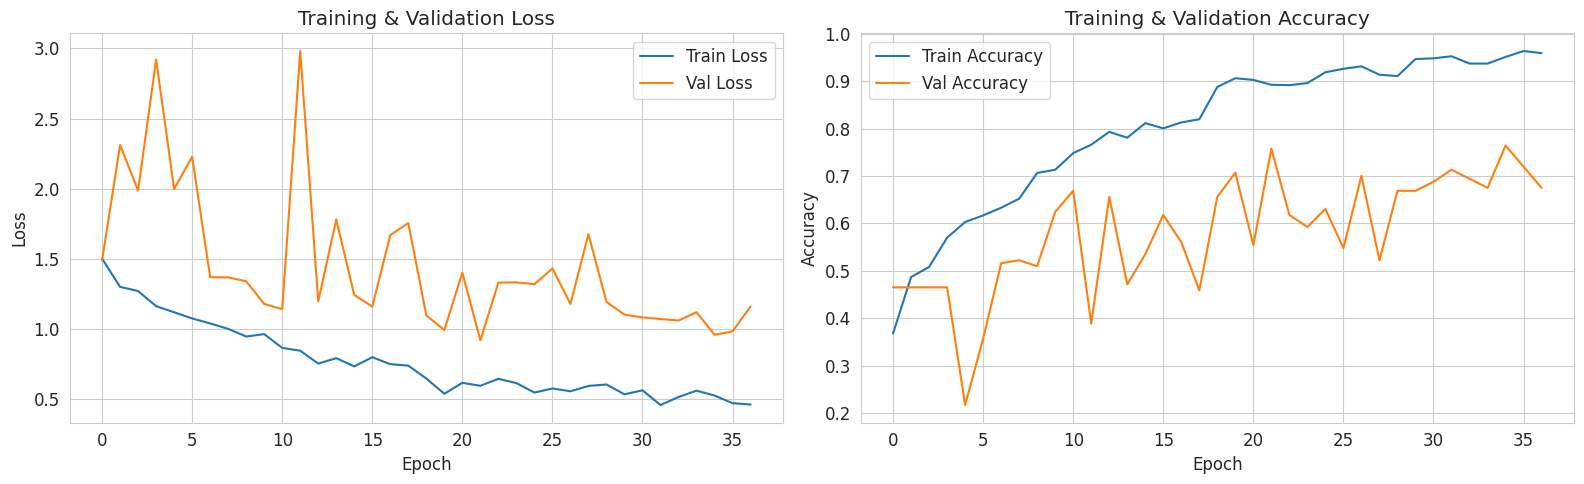

In [ ]:
# ============================================================
# Training History — Loss & Accuracy Curves (Phase 1 + 2)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

phase1_epochs = len(history_p1.history['loss'])

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].axvline(x=phase1_epochs, color='red', linestyle='--', alpha=0.7, label='Fine-tune start')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].axvline(x=phase1_epochs, color='red', linestyle='--', alpha=0.7, label='Fine-tune start')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Test Loss: 0.8212
Test Accuracy: 0.7516

Classification Report:
               precision    recall  f1-score   support

  Angry/Tense       0.43      0.23      0.30        13
 Calm/Relaxed       0.12      0.08      0.10        12
Happy/Excited       0.79      0.81      0.80        59
Sad/Depressed       0.81      0.90      0.86        73

     accuracy                           0.75       157
    macro avg       0.54      0.51      0.51       157
 weighted avg       0.72      0.75      0.73       157



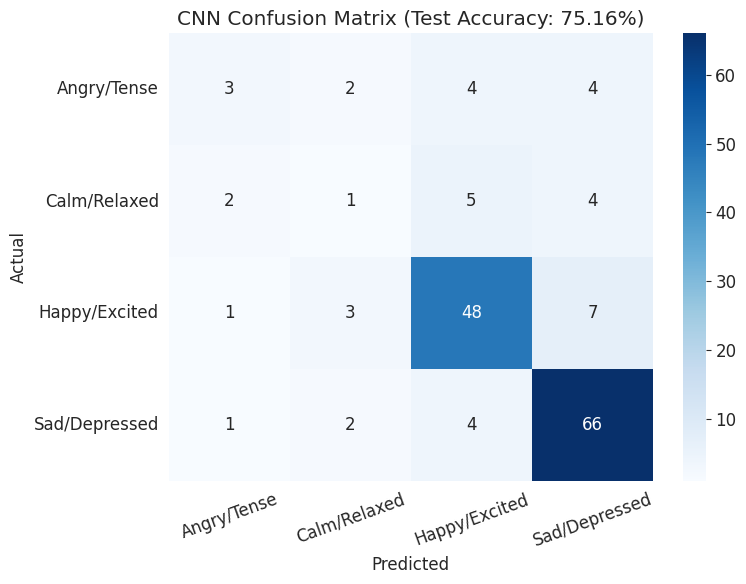


Per-class accuracy:
  Angry/Tense: 23.08% (13 samples)
  Calm/Relaxed: 8.33% (12 samples)
  Happy/Excited: 81.36% (59 samples)
  Sad/Depressed: 90.41% (73 samples)


In [14]:
# ============================================================
# Evaluate on Test Set — Classification Report & Confusion Matrix
# ============================================================

# Predictions
y_pred_prob = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Metrics
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}\n")

# Classification report
target_names = le_cnn.classes_
print("Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=target_names))

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'CNN Confusion Matrix (Test Accuracy: {test_acc:.2%})')
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\nPer-class accuracy:")
for i, cls in enumerate(target_names):
    mask = y_true_classes == i
    if mask.sum() > 0:
        acc = (y_pred_classes[mask] == i).sum() / mask.sum()
        print(f"  {cls}: {acc:.2%} ({mask.sum()} samples)")